# Tree cover per Ethnologue polygon — MODIS MOD44B (validation)

Validation of the Hansen-based `treecover_km2` using the MODIS [MOD44B Vegetation Continuous Fields](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD44B) `Percent_Tree_Cover` band (year 2000).

Inputs: MODIS tiles in `maps/raw/MODIS/` (exported from GEE at native 250m — see [`mod44b_download.ipynb`](mod44b_download.ipynb)).

Method (matches [`forestloss_ethnologue_fixed.ipynb`](forestloss_ethnologue_fixed.ipynb) exactly so values are directly comparable):
1. Merge tiles to ~1km (0.01°) with average resampling. The band stays continuous (0–100 %).
2. Build a latitude-aware per-cell area grid in km².
3. **Forest mask** = cells with `Percent_Tree_Cover > 30%` (Hansen ≥30% canopy convention) — treated as a *dichotomous* indicator (1 = forest, 0 = not), NOT a fraction.
4. km² of forest per cell = `forest_mask × cell_area_km2`.
5. Zonal-sum per Ethnologue polygon → `treecover_modis_km2`.

> Unzip any archives in `maps/raw/MODIS/` first — this notebook only globs `*.tif`.

In [22]:
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterstats import zonal_stats

import matplotlib.pyplot as plt
from rasterio.plot import show

In [23]:
base_path = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")
poscol_path = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"
modis_path = base_path / "maps" / "raw" / "MODIS"

ethnologue = gpd.read_file(poscol_path)
ethnologue = ethnologue[["ID", "geometry"]]
print(f"Number of features: {len(ethnologue)}")

Number of features: 7087


In [24]:
# --- Helpers (same as forestloss_ethnologue_fixed) -------------------------
def mosaic_1km(folder: Path):
    """Merge all .tif tiles in `folder` to ~1km resolution using average resampling."""
    files = sorted(glob(str(folder / "*.tif")))
    print(f"Found {len(files)} raster files")
    srcs  = [rasterio.open(fp) for fp in files]
    mos, trans = merge(srcs, res=(0.01, 0.01), resampling=Resampling.average)
    crs = srcs[0].crs
    for s in srcs:
        s.close()
    return mos[0].astype(np.float32), trans, crs

def pixel_area_km2_grid(transform, shape):
    """(rows, cols) array of per-cell area in km², spherical-Earth approximation."""
    rows, cols = shape
    R_km = 6371.0088
    dlat = abs(transform.e)
    dlon = abs(transform.a)
    lat_top = transform.f
    lat_centers = lat_top + (np.arange(rows) + 0.5) * transform.e
    lat_rad = np.deg2rad(lat_centers)
    dy_km = R_km * np.deg2rad(dlat)
    dx_km = R_km * np.cos(lat_rad) * np.deg2rad(dlon)
    area_row = (dx_km * dy_km).astype(np.float32)
    return np.broadcast_to(area_row[:, None], (rows, cols)).astype(np.float32)

def zonal_sum_on_array(array, transform, crs, polygons):
    """Write a float32 array to an in-memory GeoTIFF and zonal-sum it over `polygons`."""
    with MemoryFile() as mf:
        with mf.open(
            driver="GTiff",
            height=array.shape[0],
            width=array.shape[1],
            count=1,
            dtype="float32",
            transform=transform,
            crs=crs,
            nodata=np.float32(-9999.0),
        ) as dst:
            arr = np.where(np.isnan(array), np.float32(-9999.0), array).astype(np.float32)
            dst.write(arr, 1)
        stats = zonal_stats(polygons, mf.name, stats=["sum"], geojson_out=True)
    return [s["properties"]["sum"] for s in stats]

Found 6 raster files
MODIS tree cover shape: (17000, 36000) | crs: EPSG:4326


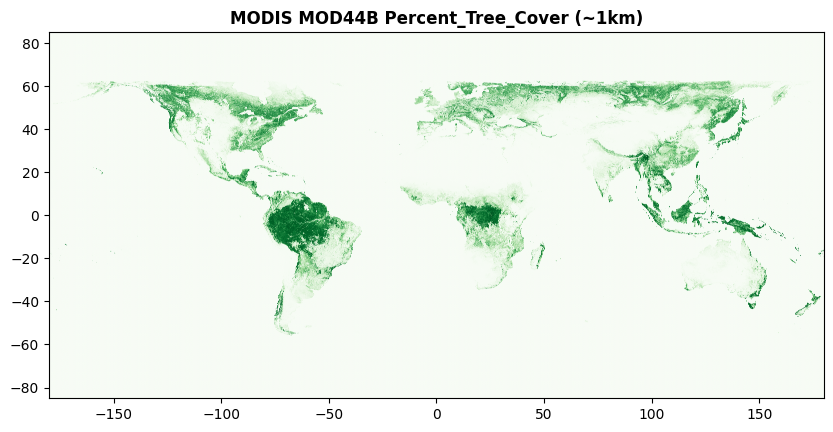

In [25]:
# --- Build MOD44B Percent_Tree_Cover mosaic (values 0–100 %) ---------------
# MOD44B uses 200 to flag water and 253 to flag fill. Mask those out before averaging
# would matter, but resampling already happened during merge. We post-filter to [0, 100].
modis_tc, trans, crs = mosaic_1km(modis_path)
print("MODIS tree cover shape:", modis_tc.shape, "| crs:", crs)

ethnologue = ethnologue.to_crs(crs)

fig, ax = plt.subplots(figsize=(10, 5))
show(np.clip(modis_tc, 0, 100), transform=trans, ax=ax, title="MODIS MOD44B Percent_Tree_Cover (~1km)", cmap="Greens")
plt.show()

In [26]:
# --- Per-cell area in km² (latitude-aware) ---------------------------------
area_km2 = pixel_area_km2_grid(trans, modis_tc.shape)
print("area_km2 range:", float(area_km2.min()), "-", float(area_km2.max()), "| mean:", float(area_km2.mean()))

area_km2 range: 0.10785184800624847 - 1.2364345788955688 | mean: 0.8302695155143738


In [27]:
# --- Weighted raster: km² of forest per cell --------------------------------
# Clip fill/water values; MOD44B valid range is 0–100.
# Forest mask = Percent_Tree_Cover > 30 (dichotomous; matches forestloss_ethnologue_fixed.ipynb).
modis_clipped = np.clip(modis_tc, 0.0, 100.0).astype(np.float32)
forest_mask   = (modis_clipped > 30).astype(np.float32)

cover_km2_cell = (forest_mask * area_km2).astype(np.float32)

print("Global total (sanity) — MODIS forest:",
      float(cover_km2_cell.sum()) / 1e6, "M km²")

Global total (sanity) — MODIS forest: 29.310048 M km²


In [28]:
# --- Zonal sum -------------------------------------------------------------
ethnologue["treecover_modis_km2"] = zonal_sum_on_array(cover_km2_cell, trans, crs, ethnologue)

ethnologue[["ID", "treecover_modis_km2"]].head()

,ID,treecover_modis_km2
0,RUS-RUS,2.735415e+06
1,ENG-USA,2.056693e+06
2,POR-BRA,3.035549e+06
3,ENG-AUS,3.201571e+05
4,CMN-CHN,6.319067e+05


In [29]:
df = ethnologue[["ID", "treecover_modis_km2"]]
print(len(df))
df.describe()

7087


,treecover_modis_km2
count,7.060000e+03
mean,3.628302e+03
std,5.900309e+04
min,0.000000e+00
25%,3.696622e+00
50%,1.172355e+02
75%,8.258921e+02
max,3.035549e+06


In [30]:
out_path = modis_path / "ethnologue_treecover_modis.csv"
df.to_csv(out_path, index=False)
print("Exported", out_path)

Exported C:\Users\juami\Dropbox\RAships\2-Folklore-Nathan-Project\EA-Maps-Nathan-project\Measures_work\maps\raw\MODIS\ethnologue_treecover_modis.csv
